In [42]:
#Test Installation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Everything works!")

Everything works!


In [43]:
#Generate Dataset
np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "customer_id": range(1, n + 1),

    "age": np.random.randint(18, 65, n),

    "gender": np.random.choice(
        ["Male", "Female"], n
    ),

    "country": np.random.choice(
        ["USA", "UK", "Canada", "Germany", "Ghana"],
        n
    ),

    "session_duration": np.random.normal(30, 10, n),

    "pages_viewed": np.random.randint(1, 50, n),

    "products_viewed": np.random.randint(1, 20, n),

    "cart_items": np.random.randint(0, 10, n),

    "purchases": np.random.randint(0, 5, n),

    "total_spent": np.random.normal(200, 80, n),

    "last_login_days": np.random.randint(1, 60, n),

    "preferred_device": np.random.choice(
        ["Mobile", "Desktop"], n
    ),

    "membership": np.random.choice(
        ["Basic", "Premium"], n
    )
})


In [44]:
data["churn"] = np.where(
    (
        (data["last_login_days"] > 30) &
        (data["purchases"] <= 2)
    ) |
    (
        (data["total_spent"] < 100) &
        (data["pages_viewed"] < 10)
    ) |
    (np.random.rand(len(data)) < 0.05),
    1,
    0
)

In [45]:
#Save Dataset
import os

# 1. Create the '../data' directory if it doesn't exist
os.makedirs("../data", exist_ok=True)

# 2. Save Dataset
data.to_csv("../data/ecommerce_customers.csv", index=False)
data.to_csv(
    "../data/ecommerce_customers.csv",
    index=False
)

In [46]:
#Preview Dataset
data.head()

,customer_id,age,gender,country,session_duration,pages_viewed,products_viewed,cart_items,purchases,total_spent,last_login_days,preferred_device,membership,churn
0,1,56,Male,Ghana,27.256474,6,9,5,3,139.772956,7,Mobile,Basic,0
1,2,46,Female,USA,35.725133,49,5,5,2,387.566946,4,Mobile,Basic,0
2,3,32,Male,UK,26.128741,17,5,1,3,175.381797,53,Mobile,Premium,0
3,4,60,Male,Ghana,30.348922,25,8,4,2,253.552872,55,Desktop,Basic,1
4,5,25,Male,Ghana,52.365529,24,2,0,0,63.060843,8,Mobile,Premium,0


# Exploratory Data Analysis (EDA)

In [47]:
#CHECK DATASET SHAPE
data.shape

(5000, 14)

In [48]:
#VIEW COLUMN INFORMATION
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   int64  
 1   age               5000 non-null   int32  
 2   gender            5000 non-null   object 
 3   country           5000 non-null   object 
 4   session_duration  5000 non-null   float64
 5   pages_viewed      5000 non-null   int32  
 6   products_viewed   5000 non-null   int32  
 7   cart_items        5000 non-null   int32  
 8   purchases         5000 non-null   int32  
 9   total_spent       5000 non-null   float64
 10  last_login_days   5000 non-null   int32  
 11  preferred_device  5000 non-null   object 
 12  membership        5000 non-null   object 
 13  churn             5000 non-null   int64  
dtypes: float64(2), int32(6), int64(2), object(4)
memory usage: 429.8+ KB


In [49]:
#SUMMARY STATISTICS
data.describe()

,customer_id,age,session_duration,pages_viewed,products_viewed,cart_items,purchases,total_spent,last_login_days,churn
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,41.16820,29.934779,25.236800,10.037200,4.593600,2.002400,201.404322,30.119000,0.34240
std,1443.520003,13.53105,10.039302,14.112723,5.457708,2.850485,1.408116,79.306769,17.060148,0.47456
min,1.000000,18.00000,-4.257954,1.000000,1.000000,0.000000,0.000000,-117.416916,1.000000,0.00000
25%,1250.750000,29.00000,23.158995,13.000000,5.000000,2.000000,1.000000,146.151416,16.000000,0.00000
50%,2500.500000,41.00000,29.887127,25.000000,10.000000,5.000000,2.000000,201.301583,30.000000,0.00000
75%,3750.250000,53.00000,36.749263,37.000000,15.000000,7.000000,3.000000,254.382250,45.000000,1.00000
max,5000.000000,64.00000,64.186122,49.000000,19.000000,9.000000,4.000000,470.579430,59.000000,1.00000


In [50]:
#CHECK MISSING VALUES
data.isnull().sum()

customer_id         0
age                 0
gender              0
country             0
session_duration    0
pages_viewed        0
products_viewed     0
cart_items          0
purchases           0
total_spent         0
last_login_days     0
preferred_device    0
membership          0
churn               0
dtype: int64

In [51]:
#CREATE ARTIFICIAL MISSING VALUES
data.loc[
    data.sample(frac=0.02).index,
    "age"
] = np.nan

In [52]:
#CHECK MISSING VALUES AGAIN
data.isnull().sum()

customer_id           0
age                 100
gender                0
country               0
session_duration      0
pages_viewed          0
products_viewed       0
cart_items            0
purchases             0
total_spent           0
last_login_days       0
preferred_device      0
membership            0
churn                 0
dtype: int64

In [53]:
#HANDLE MISSING VALUES -This replaces missing ages with the median age.
data["age"] = data["age"].fillna(
    data["age"].median()

)

In [54]:
#CHECK MISSING VALUES
data.isnull().sum()

customer_id         0
age                 0
gender              0
country             0
session_duration    0
pages_viewed        0
products_viewed     0
cart_items          0
purchases           0
total_spent         0
last_login_days     0
preferred_device    0
membership          0
churn               0
dtype: int64

In [55]:
#CHECK DUPLICATES
data.duplicated().sum()

np.int64(0)

In [56]:
#REMOVE DUPLICATES
data.drop_duplicates(inplace=True)

# Data Visualization

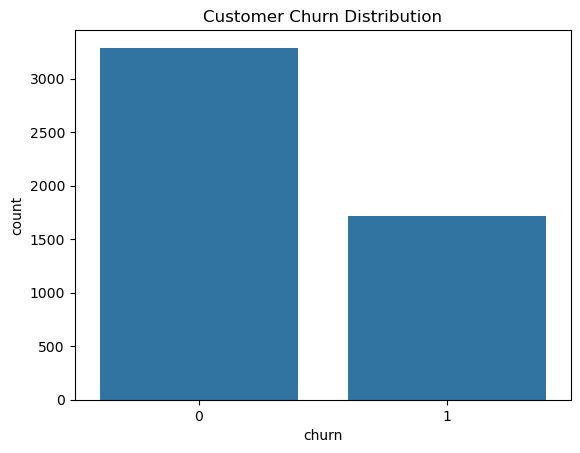

In [57]:
#CUSTOMER CHURN DISTRIBUTION
sns.countplot(
    x="churn",
    data=data
)

plt.title("Customer Churn Distribution")

plt.show()

This visualizes:

active customers
churned customers

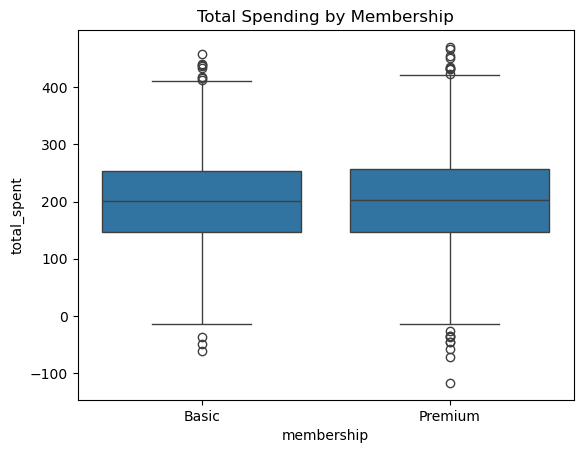

In [58]:
#MEMBERSHIP VS SPENDING
sns.boxplot(
    x="membership",
    y="total_spent",
    data=data
)

plt.title("Total Spending by Membership")




plt.show()

Insight:

compare Premium vs Basic spending

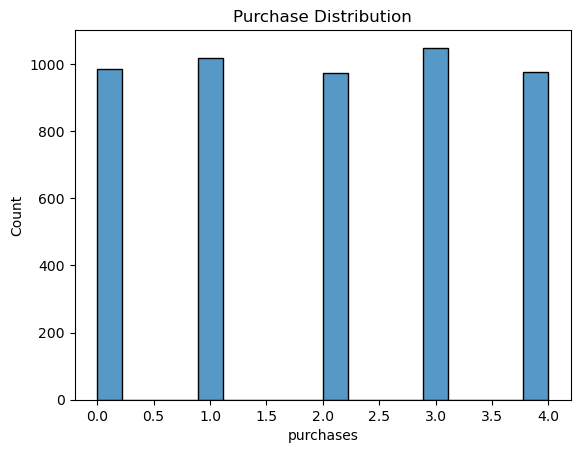

In [59]:
#PURCHASE DISTRIBUTION
sns.histplot(data["purchases"])

plt.title("Purchase Distribution")

plt.show()


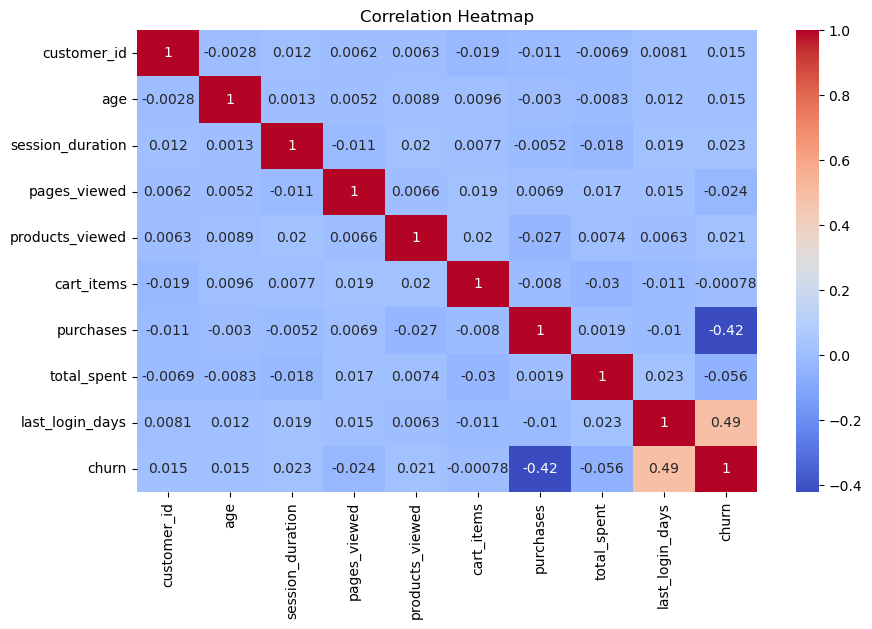

In [60]:
#CORRELATION HEATMAP
plt.figure(figsize=(10, 6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

This is VERY important for EDA.

# Feature Engineering

In [61]:
#CREATE NEW FEATURES
data["spending_per_purchase"] = (
    data["total_spent"] /
    (data["purchases"] + 1)
)

data["engagement_score"] = (
    data["pages_viewed"] +
    data["products_viewed"] +
    data["cart_items"]
)

In [62]:
data.head()

,customer_id,age,gender,country,session_duration,pages_viewed,products_viewed,cart_items,purchases,total_spent,last_login_days,preferred_device,membership,churn,spending_per_purchase,engagement_score
0,1,56.0,Male,Ghana,27.256474,6,9,5,3,139.772956,7,Mobile,Basic,0,34.943239,20
1,2,46.0,Female,USA,35.725133,49,5,5,2,387.566946,4,Mobile,Basic,0,129.188982,59
2,3,32.0,Male,UK,26.128741,17,5,1,3,175.381797,53,Mobile,Premium,0,43.845449,23
3,4,60.0,Male,Ghana,30.348922,25,8,4,2,253.552872,55,Desktop,Basic,1,84.517624,37
4,5,25.0,Male,Ghana,52.365529,24,2,0,0,63.060843,8,Mobile,Premium,0,63.060843,26


You should now see:

spending_per_purchase
engagement_score

# Data Preprocessing

In [63]:
#LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = [
    "gender",
    "country",
    "preferred_device",
    "membership"
]

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

In [64]:
#DEFINE FEATURES AND TARGET
X = data.drop(
    ["customer_id", "churn"],
    axis=1
)

y = data["churn"]

In [65]:
#SCALE FEATURES
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Predictive Modeling

In [66]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
#TRAIN RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
#MAKE PREDICTIONS
predictions = model.predict(X_test)

# Model Evaluation

In [69]:
#ACCURACY + CLASSIFICATION REPORT
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       666
           1       1.00      0.88      0.94       334

    accuracy                           0.96      1000
   macro avg       0.97      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



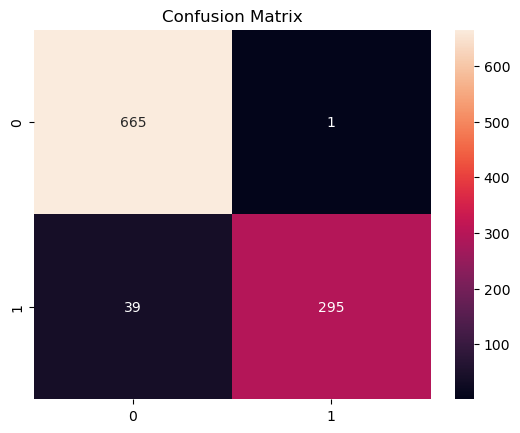

In [70]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [71]:
#CROSS VALIDATION
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5
)

print(scores)

print("Average Score:", scores.mean())

[0.961 0.968 0.958 0.968 0.962]
Average Score: 0.9633999999999998


# Feature Importance Analysis

In [72]:
#CALCULATE FEATURE IMPORTANCE
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,last_login_days,0.434111
7,purchases,0.229483
12,spending_per_purchase,0.100157
8,total_spent,0.060206
4,pages_viewed,0.032165
3,session_duration,0.030775
13,engagement_score,0.029901
0,age,0.023889
5,products_viewed,0.018639
6,cart_items,0.015869


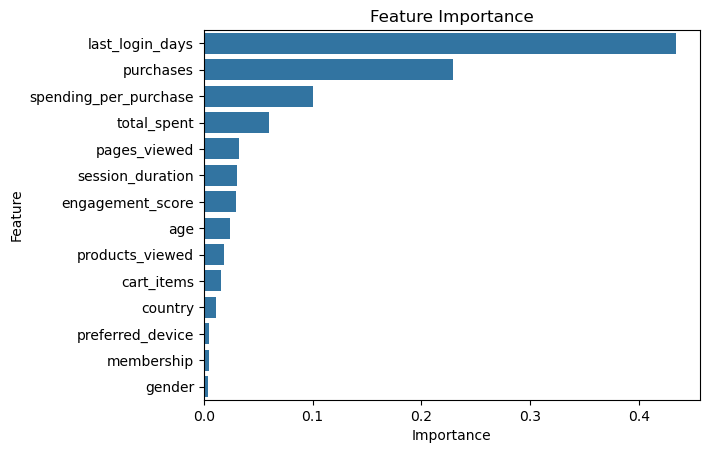

In [73]:
#FEATURE IMPORTANCE CHART
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Business Insights

1. Customers inactive for many days are more likely to churn.

2. Premium members spend more than basic members.

3. Higher engagement scores reduce churn probability.

4. Purchase frequency strongly impacts customer retention.

# Recommendations

1. Launch targeted retention campaigns.

2. Reward highly engaged customers.

3. Improve personalized recommendations.

4. Encourage repeat purchases through loyalty programs.

# Big Data Tool Utilization

Apache Kafka can be used to stream customer
interaction data in real time.

Grafana can monitor:
- customer churn
- purchasing trends
- engagement metrics

This architecture supports scalable analytics
for large e-commerce systems.

# Conclusion

This project successfully analyzed customer
behavior using synthetic e-commerce data.

Machine learning techniques were used to predict
customer churn and derive actionable insights
that can improve customer retention and sales.